<a href="https://colab.research.google.com/github/tainguyen31241022613-arch/31241022613_NguyenMinhTai_RA0001/blob/main/DEEP_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#IMPORT THƯ VIỆN & IMPOR
import numpy as np
import pandas as pd
df = pd.read_csv('/content/Data_Raw.csv', encoding='utf-8')
df.shape

(1110, 17)

In [3]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.3 MB/s eta 0:00:00


In [4]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense

In [5]:
# ===== CELL 2: THỐNG KÊ MÔ TẢ =====
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
STT,1110.0,1.115000e+02,6.411410e+01,1.000000e+00,5.600000e+01,1.115000e+02,1.670000e+02,2.220000e+02
Lợi nhuận gộp,1110.0,1.216084e+12,3.566642e+12,-2.980000e+11,7.916846e+10,2.330000e+11,6.777500e+11,4.110000e+13
Tổng cộng tài sản/Tổng tài sản,1110.0,8.144649e+12,2.059999e+13,0.000000e+00,8.505000e+11,2.035000e+12,5.760000e+12,2.580000e+14
Tổng nợ phải trả,1110.0,4.194660e+12,1.119051e+13,0.000000e+00,2.795000e+11,9.520000e+11,2.987500e+12,1.270000e+14
Nợ ngắn hạn,1110.0,2.971211e+12,7.863040e+12,0.000000e+00,2.150000e+11,7.195000e+11,2.357500e+12,9.420000e+13
Nợ dài hạn,1110.0,1.221758e+12,4.499691e+12,0.000000e+00,4.238994e+09,7.000212e+10,5.387500e+11,5.870000e+13
Lưu chuyển tiền tệ từ hoạt động kinh doanh,1110.0,4.611473e+11,1.753589e+12,-4.270000e+12,-2.200638e+10,7.085809e+10,3.005000e+11,2.670000e+13
Lưu chuyển tiền tệ từ hoạt động đầu tư,1110.0,-4.498409e+11,2.362146e+12,-2.980000e+13,-2.467500e+11,-4.161507e+10,5.342537e+09,1.690000e+13
Lưu chuyển tiền tệ từ hoạt động tài chính,1110.0,3.663302e+10,1.850804e+12,-2.480000e+13,-1.085000e+11,-9.535353e+09,1.537500e+11,2.180000e+13
Gross Profit Margin,1110.0,1.822000e-01,1.358000e-01,-1.868000e-01,8.490000e-02,1.538000e-01,2.502000e-01,1.000000e+00


In [8]:
# ===== CELL 3: TỰ ĐỘNG PHÁT HIỆN BIẾN ÂM + CHỌN METHOD =====

# Chỉnh tên cột đúng với file CSV của bạn
FEATURE_COLS = [
    'Lợi nhuận gộp', 'Tổng cộng tài sản/Tổng tài sản', 'Tổng nợ phải trả',
    'Nợ ngắn hạn', 'Nợ dài hạn',
    'Lưu chuyển tiền tệ từ hoạt động kinh doanh', 'Lưu chuyển tiền tệ từ hoạt động đầu tư', 'Lưu chuyển tiền tệ từ hoạt động tài chính',
    'Gross Profit Margin', 'Net Profit Margin', 'OPM', 'Debt-to-Asset'
]

summary = []
for col in FEATURE_COLS:
    s = df[col]
    has_negative = (s < 0).any()
    skewness     = s.skew()
    q1, q3       = s.quantile(0.25), s.quantile(0.75)
    iqr          = q3 - q1
    n_outliers   = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

    # Logic chọn method
    if has_negative:
        method = 'RobustScaler'
    elif abs(skewness) > 1 or n_outliers > len(s) * 0.05:
        method = 'RobustScaler'
    elif s.max() <= 1.0 and s.min() >= 0:
        method = 'MinMaxScaler'
    else:
        method = 'StandardScaler'

    summary.append({
        'Biến': col, 'Có âm': has_negative,
        'Skewness': round(skewness, 2),
        'N outliers (IQR)': n_outliers,
        'Method': method
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

                                      Biến  Có âm  Skewness  N outliers (IQR)       Method
                             Lợi nhuận gộp   True      5.63               157 RobustScaler
            Tổng cộng tài sản/Tổng tài sản  False      6.22               160 RobustScaler
                          Tổng nợ phải trả  False      6.36               135 RobustScaler
                               Nợ ngắn hạn  False      6.30               127 RobustScaler
                                Nợ dài hạn  False      7.27               152 RobustScaler
Lưu chuyển tiền tệ từ hoạt động kinh doanh   True      6.43               192 RobustScaler
    Lưu chuyển tiền tệ từ hoạt động đầu tư   True     -6.62               209 RobustScaler
 Lưu chuyển tiền tệ từ hoạt động tài chính   True     -1.25               226 RobustScaler
                       Gross Profit Margin   True      1.58                27 RobustScaler
                         Net Profit Margin   True     25.00                98 RobustScaler

In [9]:
# ===== CELL CHẨN ĐOÁN: XEM OUTLIER LÀ AI, NĂM NÀO =====

FEATURE_COLS = [
    'Lợi nhuận gộp', 'Tổng cộng tài sản/Tổng tài sản',
    'Tổng nợ phải trả', 'Nợ ngắn hạn', 'Nợ dài hạn',
    'Lưu chuyển tiền tệ từ hoạt động kinh doanh',
    'Lưu chuyển tiền tệ từ hoạt động đầu tư',
    'Lưu chuyển tiền tệ từ hoạt động tài chính',
    'Gross Profit Margin', 'Net Profit Margin', 'OPM', 'Debt-to-Asset'
]

print("=== TOP OUTLIER THEO TỪNG BIẾN (ngoài ngưỡng 3×IQR) ===\n")

for col in FEATURE_COLS:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mask = (s < q1 - 3*iqr) | (s > q3 + 3*iqr)
    if mask.sum() == 0:
        continue
    print(f"📌 {col}  (ngưỡng: [{(q1-3*iqr):.3f}, {(q3+3*iqr):.3f}])")
    print(df[mask][['STT', 'Mã công ty', 'Năm', col]].to_string(index=False))
    print()

=== TOP OUTLIER THEO TỪNG BIẾN (ngoài ngưỡng 3×IQR) ===

📌 Lợi nhuận gộp  (ngưỡng: [-1716576147112.000, 2473494610334.000])
 STT Mã công ty   Năm  Lợi nhuận gộp
  12        DCM  2021  2780000000000
  12        DCM  2022  5700000000000
  12        DCM  2024  2510000000000
  12        DCM  2025  4050000000000
  13        DGC  2021  3180000000000
  13        DGC  2022  6750000000000
  13        DGC  2023  3440000000000
  13        DGC  2024  3450000000000
  13        DGC  2025  3550000000000
  17        DPM  2021  4790000000000
  17        DPM  2022  7840000000000
  17        DPM  2025  2940000000000
  23        GEL  2022  4280000000000
  23        GEL  2023  3830000000000
  23        GEL  2024  3680000000000
  23        GEL  2025  4330000000000
  26        GVR  2021  7580000000000
  26        GVR  2022  6390000000000
  26        GVR  2023  4960000000000
  26        GVR  2024  6970000000000
  26        GVR  2025  8650000000000
  31        HPG  2021 41100000000000
  31        HPG  2022 168

In [10]:
# ===== CELL 4: XỬ LÝ DATA THỰC TẾ =====

# BƯỚC 1: Xóa dòng có Năm = #REF! (lỗi Excel)
print("Dòng có Năm = #REF!:")
ref_mask = df['Năm'].astype(str).str.contains('#REF', na=False)
print(df[ref_mask][['STT', 'Mã công ty', 'Năm']].to_string(index=False))
df_clean = df[~ref_mask].copy()
print(f"\n→ Đã xóa {ref_mask.sum()} dòng lỗi #REF!")
print(f"→ Còn lại: {len(df_clean)} dòng\n")

# BƯỚC 2: Xóa PTC hoàn toàn — ratio vô lý không thể dùng được
ptc_mask = df_clean['Mã công ty'] == 'PTC'
print(f"PTC có {ptc_mask.sum()} dòng — Net Profit Margin lên đến 814, OPM 581")
print("→ Không thể cứu được, loại khỏi analysis")
df_clean = df_clean[~ptc_mask].copy()

# BƯỚC 3: Với MHC, HHS, ABS, DLG — winsorize chỉ 3 cột ratio
# Lý do: công ty thật, nhưng 1-2 năm có số bất thường cực đoan
# Winsorize giữ công ty trong dataset nhưng cap giá trị về 1%-99%
from scipy.stats.mstats import winsorize

ratio_cols = ['Net Profit Margin', 'OPM', 'Gross Profit Margin']
for col in ratio_cols:
    before = df_clean[col].describe()[['min','max']].round(4)
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])
    after = df_clean[col].describe()[['min','max']].round(4)
    print(f"{col}:")
    print(f"  Trước: [{before['min']:.4f}, {before['max']:.4f}]")
    print(f"  Sau  : [{after['min']:.4f}, {after['max']:.4f}]")

print(f"\n✓ Dataset cuối: {df_clean.shape}")
print(f"✓ Số công ty còn lại: {df_clean['Mã công ty'].nunique()}")

Dòng có Năm = #REF!:
 STT Mã công ty   Năm
 117        GEE #REF!
 117        GEE #REF!
 117        GEE #REF!
 117        GEE #REF!
 118        GEX #REF!

→ Đã xóa 5 dòng lỗi #REF!
→ Còn lại: 1105 dòng

PTC có 5 dòng — Net Profit Margin lên đến 814, OPM 581
→ Không thể cứu được, loại khỏi analysis
Net Profit Margin:
  Trước: [-3.0256, 3.9538]
  Sau  : [-0.1386, 0.5830]
OPM:
  Trước: [-3.0248, 4.4538]
  Sau  : [-0.1247, 0.6381]
Gross Profit Margin:
  Trước: [-0.1868, 0.9322]
  Sau  : [-0.0158, 0.5614]

✓ Dataset cuối: (1100, 17)
✓ Số công ty còn lại: 220


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [11]:
# ===== CELL 5: SCALE SAU KHI ĐÃ CLEAN =====
from sklearn.preprocessing import RobustScaler, MinMaxScaler

FEATURE_COLS = [
    'Lợi nhuận gộp',
    'Tổng cộng tài sản/Tổng tài sản',
    'Tổng nợ phải trả',
    'Nợ ngắn hạn', 'Nợ dài hạn',
    'Lưu chuyển tiền tệ từ hoạt động kinh doanh',
    'Lưu chuyển tiền tệ từ hoạt động đầu tư',
    'Lưu chuyển tiền tệ từ hoạt động tài chính',
    'Gross Profit Margin', 'Net Profit Margin', 'OPM',
    'Debt-to-Asset'
]

df_scaled = df_clean.copy()

robust_cols = [c for c in FEATURE_COLS if c != 'Debt-to-Asset']
minmax_cols = ['Debt-to-Asset']

df_scaled[robust_cols] = RobustScaler().fit_transform(df_clean[robust_cols])
df_scaled[minmax_cols] = MinMaxScaler().fit_transform(df_clean[minmax_cols])

X = df_scaled[FEATURE_COLS].values
print(f"✓ X shape: {X.shape}")
print("\nKiểm tra (không có NaN, không có inf):")
print(f"  NaN: {np.isnan(X).sum()}")
print(f"  Inf: {np.isinf(X).sum()}")
print(f"  Max abs value: {np.abs(X).max():.4f}")

✓ X shape: (1100, 12)

Kiểm tra (không có NaN, không có inf):
  NaN: 0
  Inf: 0
  Max abs value: 117.6205


In [12]:
# ===== CELL 6: ISOLATION FOREST — PHÁT HIỆN & XỬ LÝ OUTLIER THỐNG KÊ =====
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# contamination=0.05 nghĩa là cho phép ~5% dị thường
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
outlier_labels = iso.fit_predict(X)  # 1 = normal, -1 = outlier

n_outliers = (outlier_labels == -1).sum()
print(f"Isolation Forest phát hiện: {n_outliers} outlier ({n_outliers/len(X)*100:.1f}%)")

# Xem outlier là công ty nào
outlier_idx = np.where(outlier_labels == -1)[0]
outlier_info = df_clean.iloc[outlier_idx][['STT', 'Mã công ty', 'Năm']].copy()
outlier_info['IF_score'] = iso.score_samples(X)[outlier_idx]
outlier_info = outlier_info.sort_values('IF_score')
print("\nTop 20 outlier nhất (score càng âm càng bất thường):")
print(outlier_info.head(20).to_string(index=False))

# Giữ lại chỉ normal points cho clustering
X_clean = X[outlier_labels == 1]
df_IF = df_clean.iloc[outlier_labels == 1].copy()
print(f"\n✓ Sau Isolation Forest: {X_clean.shape[0]} dòng còn lại")

Isolation Forest phát hiện: 55 outlier (5.0%)

Top 20 outlier nhất (score càng âm càng bất thường):
 STT Mã công ty  Năm  IF_score
  31        HPG 2025 -0.775123
 152        MSN 2024 -0.763145
  31        HPG 2021 -0.761157
  31        HPG 2024 -0.760591
 152        MSN 2022 -0.758664
 152        MSN 2025 -0.745827
 152        MSN 2023 -0.741154
  31        HPG 2023 -0.734063
  31        HPG 2022 -0.728382
 152        MSN 2021 -0.718453
 218        FPT 2025 -0.694458
 218        FPT 2024 -0.680409
 166        PLX 2025 -0.676623
 148        MCH 2024 -0.675407
  89        BSR 2023 -0.672771
 166        PLX 2023 -0.672246
 206        VNM 2025 -0.668021
 166        PLX 2024 -0.663999
 118        GEX 2025 -0.661334
 206        VNM 2022 -0.659255

✓ Sau Isolation Forest: 1045 dòng còn lại


In [13]:
# ===== CELL 7: TÌM K TỐI ƯU — MULTI-INDEX VALIDATION =====
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import skfuzzy as fuzz
import warnings
warnings.filterwarnings('ignore')

K_RANGE = range(2, 8)
results = []

print("Đang chạy Fuzzy C-Means cho k=2..7...")
for k in K_RANGE:
    # Fuzzy C-Means (skfuzzy nhận input shape: features x samples)
    cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
        X_clean.T, c=k, m=2.0,
        error=0.005, maxiter=1000, init=None, seed=42
    )

    # Hard label = cụm có membership cao nhất
    hard_labels = np.argmax(u, axis=0)

    sil = silhouette_score(X_clean, hard_labels)
    db  = davies_bouldin_score(X_clean, hard_labels)
    ch  = calinski_harabasz_score(X_clean, hard_labels)

    results.append({
        'k': k,
        'Silhouette ↑': round(sil, 4),
        'Davies-Bouldin ↓': round(db, 4),
        'Calinski-Harabasz ↑': round(ch, 2),
        'FPC ↑': round(fpc, 4)
    })
    print(f"  k={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.2f} | FPC={fpc:.4f}")

results_df = pd.DataFrame(results)
print("\n=== BẢNG SO SÁNH ===")
print(results_df.to_string(index=False))

Đang chạy Fuzzy C-Means cho k=2..7...
  k=2 | Sil=0.6878 | DB=1.2456 | CH=442.70 | FPC=0.8464
  k=3 | Sil=0.3533 | DB=1.9161 | CH=277.96 | FPC=0.6032
  k=4 | Sil=0.2412 | DB=1.5928 | CH=244.08 | FPC=0.5072
  k=5 | Sil=0.2234 | DB=1.6761 | CH=225.14 | FPC=0.4455
  k=6 | Sil=0.2178 | DB=1.6005 | CH=259.61 | FPC=0.4108
  k=7 | Sil=0.1388 | DB=1.7754 | CH=185.75 | FPC=0.3352

=== BẢNG SO SÁNH ===
 k  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  FPC ↑
 2        0.6878            1.2456               442.70 0.8464
 3        0.3533            1.9161               277.96 0.6032
 4        0.2412            1.5928               244.08 0.5072
 5        0.2234            1.6761               225.14 0.4455
 6        0.2178            1.6005               259.61 0.4108
 7        0.1388            1.7754               185.75 0.3352


In [14]:
# ===== CELL 8: VOTE K TỐI ƯU =====

# Normalize từng index về [0,1] rồi vote
r = results_df.copy()

# Silhouette, CH, FPC: cao hơn = tốt hơn → normalize thường
r['sil_norm'] = (r['Silhouette ↑'] - r['Silhouette ↑'].min()) / (r['Silhouette ↑'].max() - r['Silhouette ↑'].min())
r['ch_norm']  = (r['Calinski-Harabasz ↑'] - r['Calinski-Harabasz ↑'].min()) / (r['Calinski-Harabasz ↑'].max() - r['Calinski-Harabasz ↑'].min())
r['fpc_norm'] = (r['FPC ↑'] - r['FPC ↑'].min()) / (r['FPC ↑'].max() - r['FPC ↑'].min())

# Davies-Bouldin: thấp hơn = tốt hơn → đảo ngược
r['db_norm']  = 1 - (r['Davies-Bouldin ↓'] - r['Davies-Bouldin ↓'].min()) / (r['Davies-Bouldin ↓'].max() - r['Davies-Bouldin ↓'].min())

# Tổng điểm (trọng số bằng nhau)
r['total_score'] = r[['sil_norm','db_norm','ch_norm','fpc_norm']].mean(axis=1)

print("=== KẾT QUẢ VOTE ===")
print(r[['k','Silhouette ↑','Davies-Bouldin ↓','Calinski-Harabasz ↑','FPC ↑','total_score']].to_string(index=False))

best_k = r.loc[r['total_score'].idxmax(), 'k']
print(f"\n✓ K tối ưu theo multi-index vote: k = {best_k}")

=== KẾT QUẢ VOTE ===
 k  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  FPC ↑  total_score
 2        0.6878            1.2456               442.70 0.8464     1.000000
 3        0.3533            1.9161               277.96 0.6032     0.318458
 4        0.2412            1.5928               244.08 0.5072     0.308043
 5        0.2234            1.6761               225.14 0.4455     0.220276
 6        0.2178            1.6005               259.61 0.4108     0.262482
 7        0.1388            1.7754               185.75 0.3352     0.052461

✓ K tối ưu theo multi-index vote: k = 2


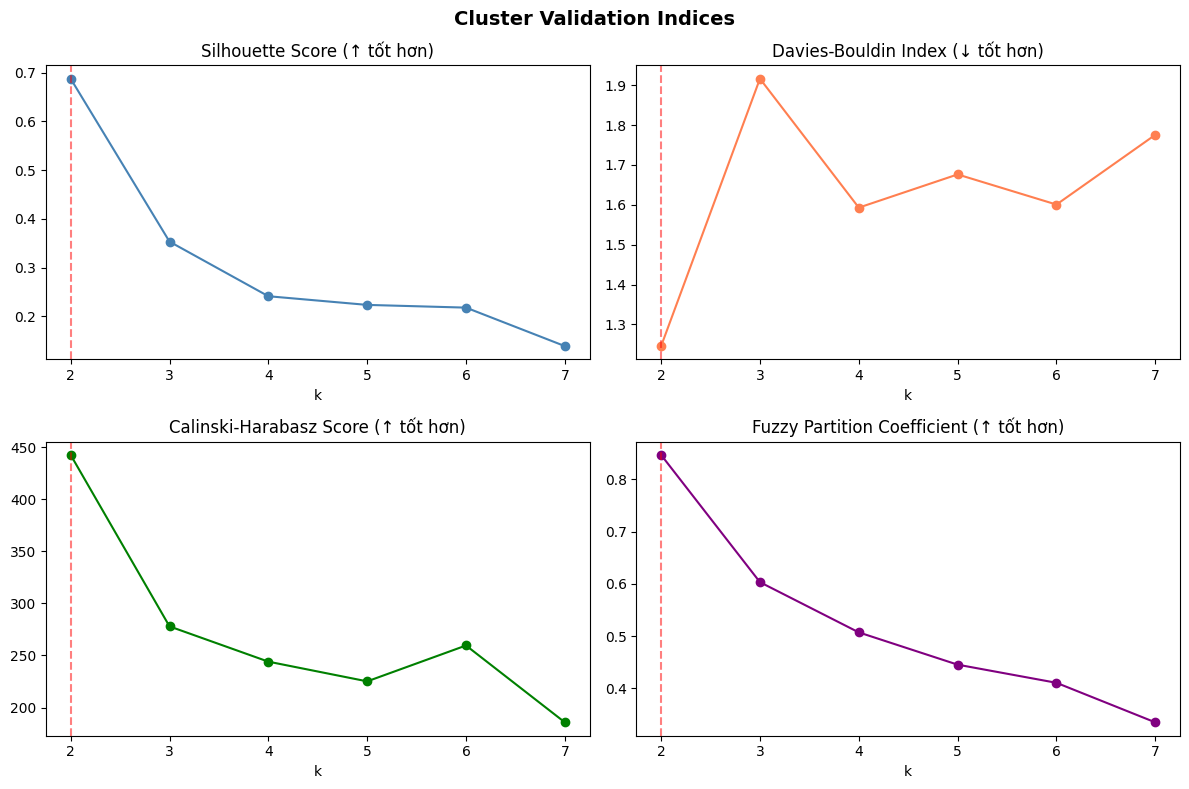

✓ Chart đã lưu: cluster_validation.png


In [15]:
# ===== CELL 9: VISUALIZE ELBOW + INDEX CHARTS =====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cluster Validation Indices', fontsize=14, fontweight='bold')

ks = list(K_RANGE)

axes[0,0].plot(ks, results_df['Silhouette ↑'], 'o-', color='steelblue')
axes[0,0].set_title('Silhouette Score (↑ tốt hơn)')
axes[0,0].set_xlabel('k'); axes[0,0].axvline(best_k, color='red', linestyle='--', alpha=0.5)

axes[0,1].plot(ks, results_df['Davies-Bouldin ↓'], 'o-', color='coral')
axes[0,1].set_title('Davies-Bouldin Index (↓ tốt hơn)')
axes[0,1].set_xlabel('k'); axes[0,1].axvline(best_k, color='red', linestyle='--', alpha=0.5)

axes[1,0].plot(ks, results_df['Calinski-Harabasz ↑'], 'o-', color='green')
axes[1,0].set_title('Calinski-Harabasz Score (↑ tốt hơn)')
axes[1,0].set_xlabel('k'); axes[1,0].axvline(best_k, color='red', linestyle='--', alpha=0.5)

axes[1,1].plot(ks, results_df['FPC ↑'], 'o-', color='purple')
axes[1,1].set_title('Fuzzy Partition Coefficient (↑ tốt hơn)')
axes[1,1].set_xlabel('k'); axes[1,1].axvline(best_k, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cluster_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Chart đã lưu: cluster_validation.png")

In [17]:
# ===== CELL 10: THỬ CLUSTER CHỈ VỚI RATIO FEATURES =====
# Loại bỏ các biến giá trị tuyệt đối (bị chi phối bởi quy mô)
# Chỉ giữ các tỷ số tài chính — phản ánh CHẤT LƯỢNG, không phải QUY MÔ

RATIO_COLS = [
    'Gross Profit Margin',
    'Net Profit Margin',
    'OPM',
    'Debt-to-Asset'
]

# Thêm các ratio tự tính nếu có thể
# CF margin = CF kinh doanh / Doanh thu (phản ánh chất lượng thu tiền)
# df_clean['CF_margin'] = (
#     df_clean['Lưu chuyển tiền tệ từ hoạt động kinh doanh'] /
#     df_clean['Doanh thu'].replace(0, np.nan)
# )

# Leverage = Tổng nợ / Tổng tài sản (khác Debt-to-Asset nếu bạn đang dùng LTD/TA)
df_clean['Leverage'] = (
    df_clean['Tổng nợ phải trả'] /
    df_clean['Tổng cộng tài sản/Tổng tài sản'].replace(0, np.nan)
)

# RATIO_COLS_EXT = RATIO_COLS + ['CF_margin', 'Leverage']
RATIO_COLS_EXT = RATIO_COLS + ['Leverage']

# Scale lại chỉ các ratio
from sklearn.preprocessing import RobustScaler
X_ratio = RobustScaler().fit_transform(
    df_clean.iloc[outlier_labels==1][RATIO_COLS_EXT].fillna(0)
)

print(f"X_ratio shape: {X_ratio.shape}")
print(f"Features: {RATIO_COLS_EXT}")

X_ratio shape: (1045, 5)
Features: ['Gross Profit Margin', 'Net Profit Margin', 'OPM', 'Debt-to-Asset', 'Leverage']


In [18]:
# ===== CELL 11: CHẠY LẠI VALIDATION VỚI RATIO FEATURES =====
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import skfuzzy as fuzz

K_RANGE = range(2, 8)
results_ratio = []

print("Chạy Fuzzy C-Means trên RATIO features...")
for k in K_RANGE:
    cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
        X_ratio.T, c=k, m=2.0,
        error=0.005, maxiter=1000, init=None, seed=42
    )
    hard_labels = np.argmax(u, axis=0)

    sil = silhouette_score(X_ratio, hard_labels)
    db  = davies_bouldin_score(X_ratio, hard_labels)
    ch  = calinski_harabasz_score(X_ratio, hard_labels)

    results_ratio.append({
        'k': k,
        'Silhouette ↑': round(sil, 4),
        'Davies-Bouldin ↓': round(db, 4),
        'Calinski-Harabasz ↑': round(ch, 2),
        'FPC ↑': round(fpc, 4)
    })
    print(f"  k={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.2f} | FPC={fpc:.4f}")

results_ratio_df = pd.DataFrame(results_ratio)

Chạy Fuzzy C-Means trên RATIO features...
  k=2 | Sil=0.4962 | DB=0.8855 | CH=922.52 | FPC=0.7831
  k=3 | Sil=0.3259 | DB=1.0391 | CH=810.80 | FPC=0.6389
  k=4 | Sil=0.3093 | DB=1.0320 | CH=782.63 | FPC=0.5578
  k=5 | Sil=0.3033 | DB=1.0147 | CH=768.87 | FPC=0.5231
  k=6 | Sil=0.2914 | DB=1.0298 | CH=724.11 | FPC=0.4747
  k=7 | Sil=0.2723 | DB=1.0738 | CH=675.19 | FPC=0.4397


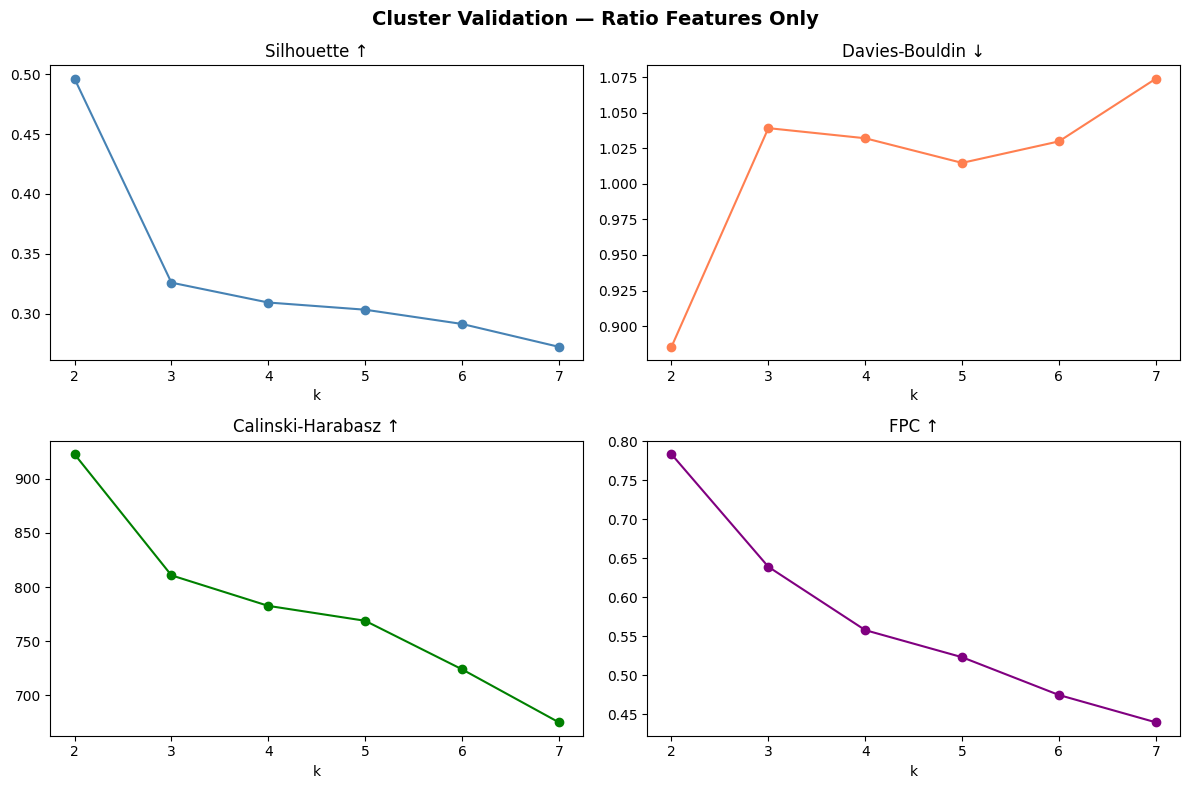

In [19]:
# ===== CELL 12: PLOT LẠI =====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cluster Validation — Ratio Features Only', fontsize=14, fontweight='bold')

ks = list(K_RANGE)
for ax, col, color in zip(axes.flat,
    ['Silhouette ↑','Davies-Bouldin ↓','Calinski-Harabasz ↑','FPC ↑'],
    ['steelblue','coral','green','purple']):
    ax.plot(ks, results_ratio_df[col], 'o-', color=color)
    ax.set_title(col); ax.set_xlabel('k')

plt.tight_layout()
plt.show()

In [20]:
# ===== CELL 13: CHẠY LẠI FUZZY FINAL VỚI k=2 & LẤY LABEL + MEMBERSHIP =====
import skfuzzy as fuzz
import numpy as np
import pandas as pd

# Chạy Fuzzy C-Means final trên X_clean (sau Isolation Forest)
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    X_clean.T, c=2, m=2.0,
    error=0.005, maxiter=1000, init=None, seed=42
)

hard_labels = np.argmax(u, axis=0)          # 0 hoặc 1
membership_healthy = u.max(axis=0)          # độ thuộc cụm mạnh nhất

# Gắn lại vào df
df_model = df_IF.copy().reset_index(drop=True)
df_model['cluster']            = hard_labels
df_model['membership']         = membership_healthy
df_model['prob_healthy_fcm']   = u[0]       # membership về cụm 0

# Xác định cụm nào là "Healthy" — cụm có mean GPM cao hơn
mean_gpm = df_model.groupby('cluster')['Gross Profit Margin'].mean()
healthy_cluster = mean_gpm.idxmax()
print(f"Healthy cluster = {healthy_cluster}  (GPM trung bình: {mean_gpm[healthy_cluster]:.4f})")
print(f"Risky  cluster  = {1 - healthy_cluster}  (GPM trung bình: {mean_gpm[1-healthy_cluster]:.4f})")

df_model['label'] = (df_model['cluster'] == healthy_cluster).astype(int)
# label=1: Healthy, label=0: Warning/Risky

print(f"\nPhân phối label:")
print(df_model['label'].value_counts().rename({1:'Healthy',0:'Warning'}))

Healthy cluster = 1  (GPM trung bình: 0.2224)
Risky  cluster  = 0  (GPM trung bình: 0.1684)

Phân phối label:
label
Warning    941
Healthy    104
Name: count, dtype: int64


In [21]:
# ===== CELL 14: BUILD SEQUENCES CHO CNN =====
# Mỗi công ty có 5 năm (2021-2025) → window=5 → predict 2026,2027,2028

from sklearn.preprocessing import RobustScaler

FEATURE_COLS_12 = [
    'Lợi nhuận gộp',
    'Tổng cộng tài sản/Tổng tài sản',
    'Tổng nợ phải trả',
    'Nợ ngắn hạn', 'Nợ dài hạn',
    'Lưu chuyển tiền tệ từ hoạt động kinh doanh',
    'Lưu chuyển tiền tệ từ hoạt động đầu tư',
    'Lưu chuyển tiền tệ từ hoạt động tài chính',
    'Gross Profit Margin', 'Net Profit Margin', 'OPM', 'Debt-to-Asset'
]

companies = df_model['Mã công ty'].unique()
print(f"Tổng số công ty: {len(companies)}")

X_seq, y_seq, meta = [], [], []

for ticker in companies:
    grp = df_model[df_model['Mã công ty'] == ticker].sort_values('Năm')

    # Chỉ lấy công ty có đủ 5 năm
    if len(grp) < 5:
        continue

    grp = grp.iloc[:5]  # 2021-2025
    features = grp[FEATURE_COLS_12].values.astype(float)

    # Label: majority vote của 5 năm → label tổng quát công ty
    label = grp['label'].mode()[0]

    X_seq.append(features)
    y_seq.append(label)
    meta.append(ticker)

X_seq = np.array(X_seq)   # shape: (n_companies, 5, 12)
y_seq = np.array(y_seq)

print(f"X_seq shape: {X_seq.shape}")
print(f"y_seq shape: {y_seq.shape}")
print(f"Số công ty đủ 5 năm: {len(meta)}")
print(f"Healthy: {y_seq.sum()} | Warning: {(y_seq==0).sum()}")

Tổng số công ty: 212
X_seq shape: (202, 5, 12)
y_seq shape: (202,)
Số công ty đủ 5 năm: 202
Healthy: 16 | Warning: 186


In [23]:
# ===== CELL 15: BUILD & TRAIN CNN =====
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_seq, y_seq, meta,
    test_size=0.2, random_state=42, stratify=y_seq
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Build CNN
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           padding='same', input_shape=(5, 12)),
    BatchNormalization(),
    Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # output: P(Healthy)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Train: (161, 5, 12) | Test: (41, 5, 12)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 5, 64)          │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 5, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,025 (50.88 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.8516 - auc: 0.3576 - loss: 0.5393 - val_accuracy: 0.9091 - val_auc: 0.6638 - val_loss: 0.5591
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - auc: 0.5518 - loss: 0.3534 - val_accuracy: 0.8788 - val_auc: 0.1250 - val_loss: 0.6709
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9219 - auc: 0.7021 - loss: 0.2489 - val_accuracy: 0.9394 - val_auc: 0.5345 - val_loss: 0.5553
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9219 - auc: 0.8417 - loss: 0.2049 - val_accuracy: 0.7879 - val_auc: 0.8190 - val_loss: 0.4489
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9297 - auc: 0.9225 - loss: 0.1672 - val_accuracy: 0.7576 - val_auc: 0.8879 - val_loss: 0.3958
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9297 - auc: 0.9599 - loss: 0.1354 - val_accuracy: 0.8182 - val_auc: 0.8879 - val_loss: 0.3372
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step -

Test Accuracy: 0.9268
Test AUC:      0.9649

Classification Report:
              precision    recall  f1-score   support

     Warning       0.97      0.95      0.96        38
     Healthy       0.50      0.67      0.57         3

    accuracy                           0.93        41
   macro avg       0.74      0.81      0.77        41
weighted avg       0.94      0.93      0.93        41



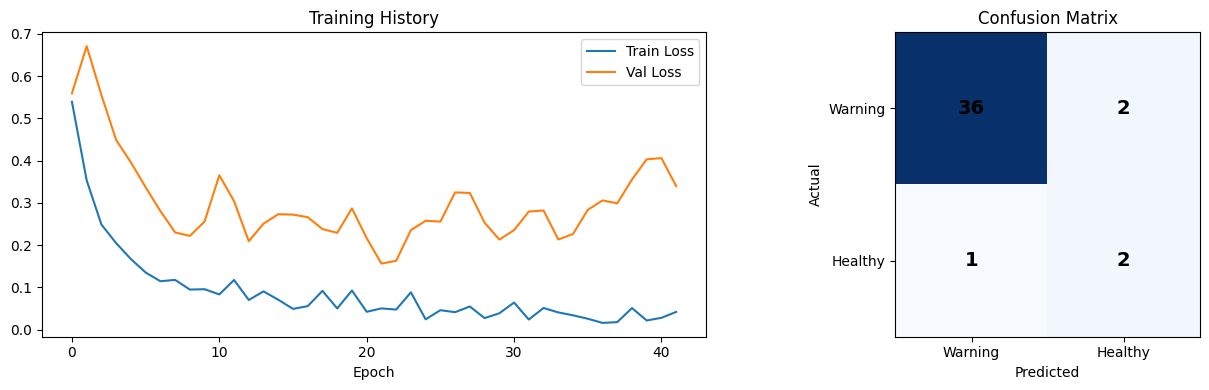

In [24]:
# ===== CELL 16: EVALUATE =====
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

loss, acc, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test AUC:      {auc:.4f}")

y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Warning','Healthy']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training history
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training History')
axes[0].set_xlabel('Epoch'); axes[0].legend()

# Confusion matrix
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Warning','Healthy'])
axes[1].set_yticklabels(['Warning','Healthy'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center',
                     fontsize=14, fontweight='bold')
axes[1].set_title('Confusion Matrix'); axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('cnn_eval.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ===== CELL 17 FIX: TÍNH TOÁN TRƯỚC, KHÔNG VẼ =====
summary_rows = []

print("Đang tính CNN predictions...")
for i, ticker in enumerate(meta):
    seq = X_seq[i]

    # CNN prob lịch sử
    cnn_hist = []
    for t in range(5):
        start = max(0, t - 4)
        window = seq[start:t+1]
        if len(window) < 5:
            pad = np.repeat(window[[0]], 5 - len(window), axis=0)
            window = np.vstack([pad, window])
        prob = model.predict(window[np.newaxis], verbose=0)[0][0]
        cnn_hist.append(float(prob))

    # FCM membership
    fcm_hist = get_fcm_hist(ticker)
    if len(fcm_hist) < 5:
        fcm_hist = [fcm_hist[0]] * (5 - len(fcm_hist)) + fcm_hist

    # Predict 2026-2028
    cnn_pred = predict_future(seq)

    summary_rows.append({
        'Mã công ty': ticker,
        'fcm_hist':   fcm_hist,
        'cnn_hist':   cnn_hist,
        'cnn_pred':   cnn_pred,
        'CNN_2026':   round(cnn_pred[0], 4),
        'CNN_2027':   round(cnn_pred[1], 4),
        'CNN_2028':   round(cnn_pred[2], 4),
        'Trend':      'Improving' if cnn_pred[2] > cnn_pred[0] else 'Declining',
        'Status_2028':'Healthy' if cnn_pred[-1] >= 0.5 else 'Warning'
    })

    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(meta)} done...")

summary_df = pd.DataFrame(summary_rows)
print(f"\n✓ Tính xong {len(summary_df)} công ty")
print(summary_df['Status_2028'].value_counts())
summary_df[['Mã công ty','CNN_2026','CNN_2027','CNN_2028','Trend','Status_2028']].to_csv(
    'forecast_summary.csv', index=False)
print("✓ Lưu: forecast_summary.csv")

Đang tính CNN predictions...
  20/202 done...
  40/202 done...
  60/202 done...
  80/202 done...
  100/202 done...
  120/202 done...
  140/202 done...
  160/202 done...
  180/202 done...
  200/202 done...

✓ Tính xong 202 công ty
Status_2028
Warning    178
Healthy     24
Name: count, dtype: int64
✓ Lưu: forecast_summary.csv


In [28]:
# ===== CELL 18: HÀM VẼ — TÁCH RIÊNG =====
import matplotlib
matplotlib.use('Agg')   # không render GUI, nhanh hơn nhiều
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('company_charts', exist_ok=True)

YEARS_HIST = [2021, 2022, 2023, 2024, 2025]
YEARS_PRED = [2026, 2027, 2028]

def plot_company_fast(row):
    ticker    = row['Mã công ty']
    fcm_hist  = row['fcm_hist']
    cnn_hist  = row['cnn_hist']
    cnn_pred  = row['cnn_pred']
    all_years = YEARS_HIST + YEARS_PRED
    all_probs = cnn_hist + cnn_pred

    fig, ax = plt.subplots(figsize=(10, 5))

    # Vùng nền Healthy/Warning
    for yr, prob in zip(all_years, all_probs):
        color = '#c8e6c9' if prob >= 0.5 else '#ffe0b2'
        ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.4, color=color, zorder=0)

    # FCM
    ax.plot(YEARS_HIST, fcm_hist, 's--', color='#388e3c',
            linewidth=1.5, markersize=7, label='FCM Membership (Healthy)')

    # CNN historical
    ax.plot(YEARS_HIST, cnn_hist, 'o-', color='#1565c0',
            linewidth=2, markersize=8, label='CNN P(Healthy) — Historical')

    # CNN forecast
    ax.plot(YEARS_PRED, cnn_pred, 'o--', color='#1565c0',
            linewidth=2, markersize=8, label='CNN P(Healthy) — Forecast')

    # Nối 2025→2026
    ax.plot([2025, 2026], [cnn_hist[-1], cnn_pred[0]],
            '--', color='#1565c0', linewidth=2)

    # Annotate — dùng text thay vì annotate để nhanh hơn
    for yr, prob in zip(all_years, all_probs):
        status    = "Healthy" if prob >= 0.5 else "Warning"
        color_txt = '#1b5e20' if prob >= 0.5 else '#e65100'
        ax.text(yr, prob + 0.04, f"{status}\n{prob:.2f}",
                ha='center', fontsize=7.5,
                color=color_txt, fontweight='bold')

    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.axvline(2025.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_xlim(2020.5, 2028.5)
    ax.set_ylim(0.3, 1.2)
    ax.set_xticks(all_years)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('CNN Probability (Healthy)', fontsize=11)
    ax.set_title(f'Financial Health Assessment — {ticker}',
                 fontsize=13, fontweight='bold')

    healthy_patch = mpatches.Patch(color='#c8e6c9', alpha=0.6, label='Healthy zone')
    warning_patch = mpatches.Patch(color='#ffe0b2', alpha=0.6, label='Warning zone')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [healthy_patch, warning_patch],
              labels  + ['Healthy zone', 'Warning zone'],
              loc='lower left', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'company_charts/{ticker}.png', dpi=120, bbox_inches='tight')
    plt.close('all')   # quan trọng: đóng figure sau mỗi lần vẽ

print("✓ Hàm plot_company_fast sẵn sàng")

✓ Hàm plot_company_fast sẵn sàng


In [29]:
# ===== CELL 19: VẼ THEO BATCH 20 CÔNG TY =====
# Chạy cell này nhiều lần — mỗi lần 1 batch
# Thay BATCH_NUM = 0, 1, 2, ... cho đến hết

BATCH_SIZE = 20
BATCH_NUM  = 0       # ← đổi số này mỗi lần chạy

start = BATCH_NUM * BATCH_SIZE
end   = min(start + BATCH_SIZE, len(summary_df))
batch = summary_df.iloc[start:end]

print(f"Vẽ batch {BATCH_NUM}: công ty {start+1} → {end} / {len(summary_df)}")

for _, row in batch.iterrows():
    plot_company_fast(row)
    print(f"  ✓ {row['Mã công ty']}")

print(f"\nBatch {BATCH_NUM} xong! "
      f"Đổi BATCH_NUM = {BATCH_NUM+1} rồi chạy lại cell này.")

Vẽ batch 0: công ty 1 → 20 / 202
  ✓ AAA
  ✓ ABS
  ✓ ACG
  ✓ ADP
  ✓ APH
  ✓ BFC
  ✓ BKG
  ✓ BMC
  ✓ C32
  ✓ CSV
  ✓ CVT
  ✓ DCM
  ✓ DHA
  ✓ DHC
  ✓ DHM
  ✓ DPM
  ✓ DPR
  ✓ DTL
  ✓ DTT
  ✓ DXV

Batch 0 xong! Đổi BATCH_NUM = 1 rồi chạy lại cell này.


In [30]:
# ===== CELL 21: NÉN TẤT CẢ CHART → 1 FILE ZIP ĐỂ TẢI VỀ =====
import zipfile, glob

with zipfile.ZipFile('company_charts.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in glob.glob('company_charts/*.png'):
        zf.write(f)

print(f"✓ Đã nén xong: company_charts.zip")

# Download
from google.colab import files
files.download('company_charts.zip')
files.download('forecast_summary.csv')

✓ Đã nén xong: company_charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>